In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\keert\Projects\BA_1\data\amazon_reviews_electronics.csv")

# --- Drop columns not needed for analysis ---
df = df.drop(columns=['images', 'user_id', 'parent_asin'])

# --- Fix types ---
df['rating']           = df['rating'].astype(float)
df['helpful_vote']     = pd.to_numeric(df['helpful_vote'], errors='coerce').fillna(0).astype(int)
df['verified_purchase'] = df['verified_purchase'].astype(bool)

# --- Parse timestamp (Unix milliseconds) ---
df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M')

# --- Drop rows missing the essentials ---
df = df.dropna(subset=['rating', 'text'])
df = df[df['text'].str.strip().str.len() > 10]  # remove blank/junk reviews

# --- Add review length column ---
df['review_length'] = df['text'].str.split().str.len()

# --- Sentiment label from star rating ---
df['sentiment'] = df['rating'].apply(
    lambda r: 'positive' if r >= 4 else ('negative' if r <= 2 else 'neutral')
)

print(f"Clean dataset: {df.shape}")
print(df.dtypes)
print(f"\nDate range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nSentiment breakdown:\n{df['sentiment'].value_counts()}")
print(f"\nVerified purchase: {df['verified_purchase'].value_counts().to_dict()}")

Clean dataset: (104986, 13)
rating                      float64
title                           str
text                            str
asin                            str
timestamp                     int64
helpful_vote                  int64
verified_purchase              bool
date                 datetime64[ms]
year                          int32
month                         int32
year_month                period[M]
review_length                 int64
sentiment                       str
dtype: object

Date range: 2000-01-06 → 2023-09-11

Sentiment breakdown:
sentiment
positive    79168
negative    18774
neutral      7044
Name: count, dtype: int64

Verified purchase: {True: 96845, False: 8141}


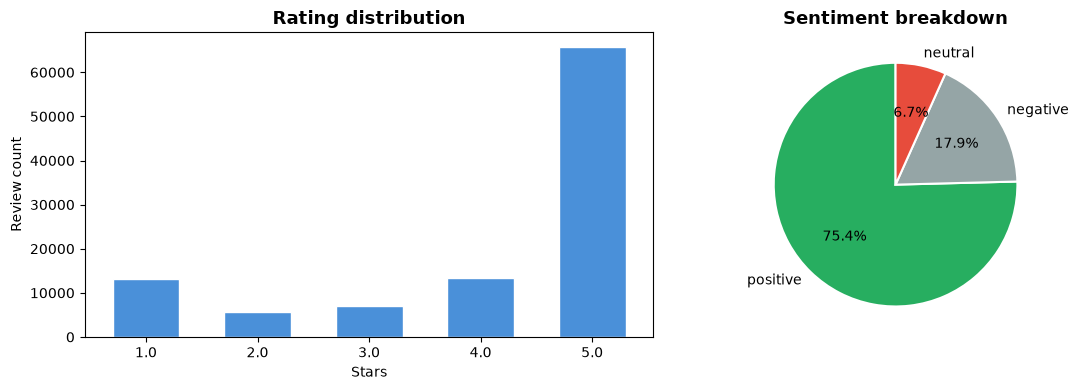

Saved ✓


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: rating counts
df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#4A90D9', edgecolor='white', width=0.6
)
axes[0].set_title("Rating distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Review count")
axes[0].tick_params(axis='x', rotation=0)

# Right: sentiment pie
colors = ['#27AE60', '#95A5A6', '#E74C3C']
sentiment_counts = df['sentiment'].value_counts()
axes[1].pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title("Sentiment breakdown", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

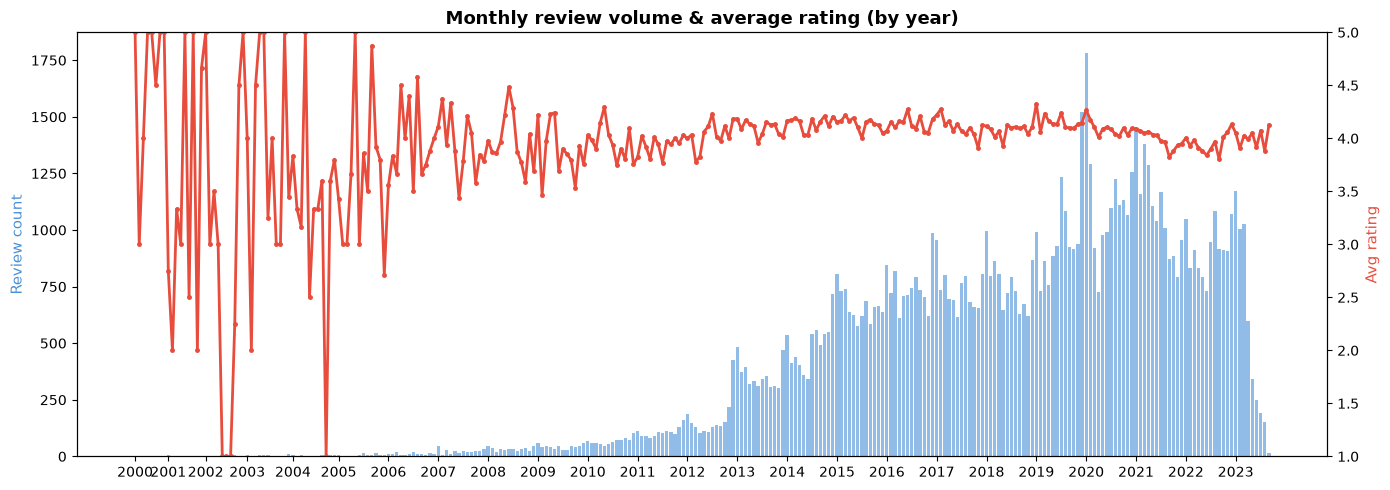

Saved ✓


In [10]:
monthly = df.groupby('year_month').agg(
    review_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))

x = range(len(monthly))

# Bar: volume
ax1.bar(x, monthly['review_count'], color='#4A90D9', alpha=0.6, label='Review count')
ax1.set_ylabel("Review count", color='#4A90D9', fontsize=11)

# Line: avg rating
ax2 = ax1.twinx()
ax2.plot(x, monthly['avg_rating'], color='#E74C3C',
         linewidth=2, marker='o', markersize=2.5, label='Avg rating')
ax2.set_ylabel("Avg rating", color='#E74C3C', fontsize=11)
ax2.set_ylim(1, 5)

# --- Fix: show only year labels, not every month ---
yearly_ticks = []
yearly_labels = []
current_year = None
for i, ym in enumerate(monthly['year_month_str']):
    year = ym[:4]
    if year != current_year:
        yearly_ticks.append(i)
        yearly_labels.append(year)
        current_year = year

ax1.set_xticks(yearly_ticks)
ax1.set_xticklabels(yearly_labels, rotation=0, fontsize=10)

plt.title("Monthly review volume & average rating (by year)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("reviews_over_time.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

=== Verified vs Unverified Purchase Analysis ===
                   count  avg_rating  pct_negative
verified_purchase                                 
False               8141        3.79         24.20
True               96845        4.10         17.35


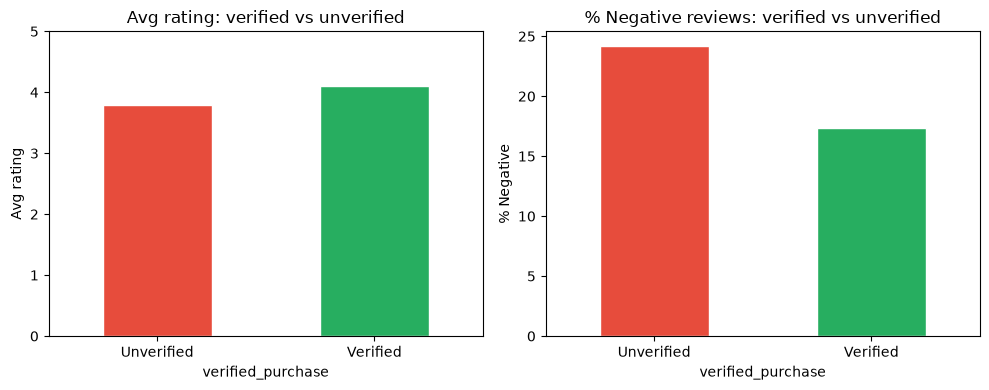

In [7]:
verified = df.groupby('verified_purchase').agg(
    count=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    pct_negative=('sentiment', lambda x: (x == 'negative').mean() * 100)
).round(2)

print("=== Verified vs Unverified Purchase Analysis ===")
print(verified)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

verified['avg_rating'].plot(kind='bar', ax=axes[0],
    color=['#E74C3C', '#27AE60'], edgecolor='white', width=0.5)
axes[0].set_title("Avg rating: verified vs unverified")
axes[0].set_xticklabels(['Unverified', 'Verified'], rotation=0)
axes[0].set_ylabel("Avg rating")
axes[0].set_ylim(0, 5)

verified['pct_negative'].plot(kind='bar', ax=axes[1],
    color=['#E74C3C', '#27AE60'], edgecolor='white', width=0.5)
axes[1].set_title("% Negative reviews: verified vs unverified")
axes[1].set_xticklabels(['Unverified', 'Verified'], rotation=0)
axes[1].set_ylabel("% Negative")

plt.tight_layout()
plt.savefig("verified_vs_unverified.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("=== Helpful Vote Stats ===")
print(df['helpful_vote'].describe())

# Do negative reviews get more helpful votes? (people agree with complaints)
helpful_by_sentiment = df.groupby('sentiment')['helpful_vote'].agg(['mean', 'median', 'sum'])
print("\nHelpful votes by sentiment:")
print(helpful_by_sentiment.round(2))

# Top 10 most helpful reviews
top_helpful = df.nlargest(10, 'helpful_vote')[['rating', 'title', 'text', 'helpful_vote', 'sentiment']]
print("\nTop 10 most helpful reviews:")
print(top_helpful[['rating', 'helpful_vote', 'sentiment', 'title']])

=== Helpful Vote Stats ===
count    104986.000000
mean          1.069581
std          14.712933
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        2735.000000
Name: helpful_vote, dtype: float64

Helpful votes by sentiment:
           mean  median    sum
sentiment                     
negative   1.51     0.0  28365
neutral    1.15     0.0   8111
positive   0.96     0.0  75815

Top 10 most helpful reviews:
       rating  helpful_vote sentiment  \
2577      5.0          2735  positive   
69071     5.0          2012  positive   
3174      4.0          1684  positive   
48670     5.0           809  positive   
21938     5.0           681  positive   
78342     1.0           670  negative   
37958     5.0           624  positive   
33504     3.0           575   neutral   
2273      5.0           568  positive   
36243     1.0           545  negative   

                                                   title  
2577   [NEW] OontZ Angle3 :: 

=== Review length by sentiment ===
             count  mean   std  min   25%   50%   75%     max
sentiment                                                    
negative   18774.0  55.9  74.7  1.0  16.0  33.0  67.0  1259.0
neutral     7044.0  65.2  92.1  1.0  18.0  38.0  78.0  1882.0
positive   79168.0  42.7  71.9  1.0   9.0  22.0  48.0  3869.0


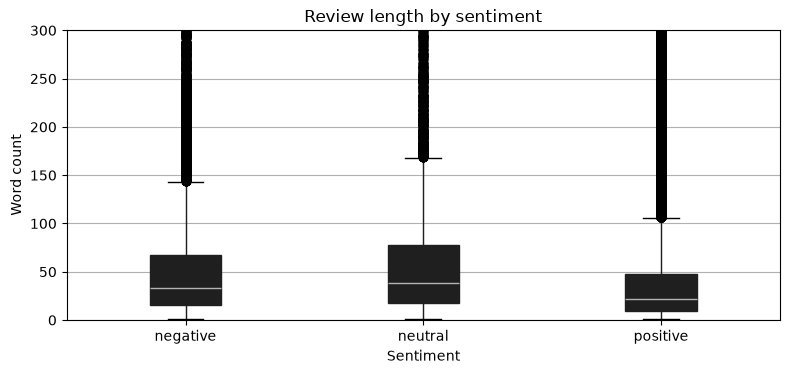

In [9]:
print("=== Review length by sentiment ===")
print(df.groupby('sentiment')['review_length'].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='review_length', by='sentiment', ax=ax,
           patch_artist=True)
ax.set_ylim(0, 300)   # cap at 300 words — outliers skew the chart
ax.set_title("Review length by sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Word count")
plt.suptitle("")
plt.tight_layout()
plt.savefig("review_length_sentiment.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
df.to_csv(r"C:\Users\keert\Projects\BA_1\data\amazon_reviews_electronics.csv", index=False)
print(f"Saved clean file: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
print("\nEDA complete ✓ — ready for sentiment modeling (Project 1A) and SQL load (Project 1B)")

Saved clean file: 104,986 rows, 13 columns
Columns: ['rating', 'title', 'text', 'asin', 'timestamp', 'helpful_vote', 'verified_purchase', 'date', 'year', 'month', 'year_month', 'review_length', 'sentiment']

EDA complete ✓ — ready for sentiment modeling (Project 1A) and SQL load (Project 1B)
